# Study · Do three thermometers tell the same story?

Three independent sources now measure the environment at Gubbio, and the
project has used only one of them.

| Source | Suffix | What it measures |
|---|---|---|
| Logger on the wall | `_str` | Air inside the instrument housing |
| Ground station, Gubbio town | `_gs` | Standard exposure, in town |
| ERA5 reanalysis | `_era5` | Average over a ~9 km grid cell |

**They are not replicates.** A housing on a sun-exposed wall, a screen in town
and a nine-kilometre grid average are three different quantities that happen to
share a name. Disagreement is expected; this study measures it and says what it
costs.

## Why it has to be settled first

`studies/unified_dataset/` established that the on-structure channels vanish
with the target — on 100 % of the hours the inclinometer is missing, so are air
temperature, humidity and battery. An independent source is the only escape,
and the ground station is present on **88.9 %** of exactly those hours.

Whether that availability is *useful* depends on whether the proxy carries the
same relationship with the wall. That is what is measured here.

## Two rules

**The target is fixed.** `inc_comp` is the calibrated reading — the
manufacturer's formula applied with the temperature measured at the transducer.
That is an instrument calibration, not a regression, so nothing here
re-estimates its coefficient and no alternative target is constructed. That the
on-structure temperature appears inside it is a property of the calibrated
measurement, stated once and not designed around.

**The clock is measured, not assumed.** The sources do not share a time
convention, and an uncorrected offset would misplace every diurnal phase in the
study. Step 1 settles it two independent ways.

## Imports and configuration

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../../..'))

import pc_lib as pc
import ud_lib as ud
import ip_lib as ip
import tc_lib as tc

pd.set_option('display.width', 180)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 100)

### Parameters

| Parameter | Purpose |
|---|---|
| `UNIFIED_DIR` | Where `build_unified_dataset.py` wrote the sensor tables. |
| `PROXY_DIR` | The two proxy exports. |
| `DICT_PATH` | Where the generated data dictionary is written. |
| `QUANTITIES` | Canonical quantities compared across sources. |
| `MIN_OVERLAP_DAYS` | Shortest overlap for which a statistic is reported. |
| `MAX_DELAY_H` | Delay bound for external forcings, per docs §7.5. |

In [2]:
UNIFIED_DIR = '../../../data/interim/unified'
PROXY_DIR = '../../../data/raw/proxies'
DICT_PATH = '../../../docs/proxy-data-dictionary.md'
OUTPUT_DIR = 'outputs'
STATION = ud.TARGET_STATION

TARGET = pc.TARGET                 # inc_comp — the calibrated reading
QUANTITIES = ['tair', 'rh', 'sr']
MIN_OVERLAP_DAYS = 30
MAX_DELAY_H = 12
DELAYS = list(range(0, MAX_DELAY_H + 1))
TAUS = [0, 1, 2, 3, 4, 6, 8, 12, 18, 24, 36, 48, 72, 96, 120, 168]
DETREND_HOURS = 168
SAMPLING_HOURS = 1.0

os.makedirs(OUTPUT_DIR, exist_ok=True)
pc.set_context('notebook')

'notebook'

## Step 1 · Harmonise, name, and fix the clock

Three sources onto one grid, under one naming scheme, with units reconciled.

In [3]:
sensor = pc.alias_structure(ud.load_unified(UNIFIED_DIR, STATION))
ground = pc.load_ground_station(f'{PROXY_DIR}/meteosystem_gubbio.csv')
era5 = pc.load_era5(f'{PROXY_DIR}/oikolab_weather.csv')

raw = sensor.join(ground, how='outer').join(era5, how='outer')
print(f'joined: {raw.shape[0]} hourly slots, '
      f'{raw.index.min()} to {raw.index.max()}')
print(f'ground station: native step {ground.attrs["native_step"]}, '
      f'{ground.attrs["duplicates_dropped"]} duplicate timestamps dropped')

joined: 75505 hourly slots, 2018-01-01 00:00:00 to 2026-08-13 00:00:00
ground station: native step 0 days 00:30:00, 124 duplicate timestamps dropped


### What arrived, and whether it is plausible

Values outside the plausible range are **reported, not removed**. A radiation
channel reading sixty watts at midnight is a finding about the sensor, and
deleting it would hide the finding.

In [4]:
inventory = pc.harmonisation_report(raw)
display(inventory[['quantity', 'source', 'unit', 'coverage_%', 'min', 'max',
                   'mean', 'outside_plausible']])
inventory.to_csv(f'{OUTPUT_DIR}/P_01_channel_inventory.csv')

defects = inventory[inventory['outside_plausible'] > 0]
if len(defects):
    print('\nChannels carrying implausible values:')
    display(defects[['quantity', 'source', 'min', 'max', 'outside_plausible']])

,quantity,source,unit,coverage_%,min,max,mean,outside_plausible
channel,,,,,,,,
tair_str,tair,str,degC,65.5,-5.17,3.893000e+01,13.93,0
rh_str,rh,str,%,65.5,19.17,1.000000e+02,74.80,0
sr_str,sr,str,W/m2,11.8,0.00,1.358000e+03,244.66,0
twall_str,twall,str,degC,6.3,1.25,5.556000e+01,23.28,0
tair_gs,tair,gs,degC,88.6,-5.45,3.820000e+01,14.66,0
rh_gs,rh,gs,%,86.0,1.00,9.750000e+01,66.99,0
sr_gs,sr,gs,W/m2,88.7,0.00,1.072500e+03,147.06,0
tdew_gs,tdew,gs,degC,88.6,-19.90,2.390000e+01,7.68,0
pres_gs,pres,gs,hPa,87.6,939.65,9.929000e+02,968.33,0



Channels carrying implausible values:


,quantity,source,min,max,outside_plausible
channel,,,,,
rain_gs,rain,gs,0.0,1.703392e+09,1


### The clock, settled two ways

**The absolute test** compares each source's solar-radiation phase against
solar noon computed from the site's longitude and the equation of time. It
needs no reference sensor.

**The relative test** cross-correlates each source against the on-structure
channel. It needs a reference but works on any quantity.

Where the two disagree for a source, one of its channels is defective — and
knowing which one is the point of running both.

In [5]:
evidence = pc.clock_evidence(raw, reference='str')
display(evidence)
evidence.to_csv(f'{OUTPUT_DIR}/P_02_clock_test.csv', index=False)

,source,season,n_days,sun_offset_h,sun_shift_h,rel_tair_shift_h,rel_tair_r,rel_sr_shift_h,rel_sr_r
0,str,winter,87,0.77,1,NaN,NaN,NaN,NaN
1,str,summer,115,1.26,1,NaN,NaN,NaN,NaN
2,gs,winter,676,0.09,0,0.0,0.9528,1.0,0.1346
3,gs,summer,714,0.06,0,1.0,0.9609,1.0,0.8090
4,era5,winter,772,0.51,1,0.0,0.9034,0.0,0.1379
5,era5,summer,799,0.42,0,1.0,0.9402,1.0,0.8067


**The on-structure radiation channel fails its own consistency check.** It puts
solar noon *after* its own daily temperature maximum, which is impossible, and
its winter estimate has an interquartile range of several hours. It also reads
a non-zero value at midnight. The alignment is therefore taken from **air
temperature**, which all three sources carry with good coverage and which is
the quantity the rest of the study uses.

On temperature the answer is unambiguous: the ground station and ERA5 agree
with each other exactly in both seasons, and both sit one hour from the
on-structure logger **in summer only**. That is a daylight-saving mismatch, so
the correction is applied by season rather than as one annual figure.

In [6]:
CLOCK_OFFSETS = {'gs': (0, 1), 'era5': (0, 1)}     # (winter, summer), in hours
df = pc.apply_seasonal_clock(raw, CLOCK_OFFSETS)

residual = pc.clock_offset(df, quantity='tair', reference='str')
display(residual)

assert (residual['best_shift_h'] == 0).all(), \
    'clock guard: a residual offset survives the correction'
print('Clock guard passed: no residual offset on any source or season.')

,source,season,best_shift_h,r_at_best,r_at_zero,n
0,gs,winter,0,0.9528,0.9528,13968
1,gs,summer,0,0.9610,0.9610,11462
2,era5,winter,0,0.9034,0.9034,14197
3,era5,summer,0,0.9405,0.9405,12275


Clock guard passed: no residual offset on any source or season.


### The radiation channels themselves

Every other figure in this study reports a statistic. This one reports the
measurements, because for solar radiation the raw channel is where the
on-structure defect is directly visible and no average will show it.

The panels are restricted to the period the on-structure pyranometer covers,
which is the only window over which the three sources can be compared at all.
The proxies run from 2018 and that difference in extent is reported in
Section 5's tier inventory; drawing it here would leave the on-structure panel
almost entirely empty and hide the comparison this figure exists to show.

The top panels carry the hourly values for range and a thirty-day rolling
maximum for the seasonal ceiling, one source each. The bottom panel overlays
all three at full hourly resolution over the fortnight in which they are
jointly most complete, which is the only scale at which an individual hourly
value can be read.

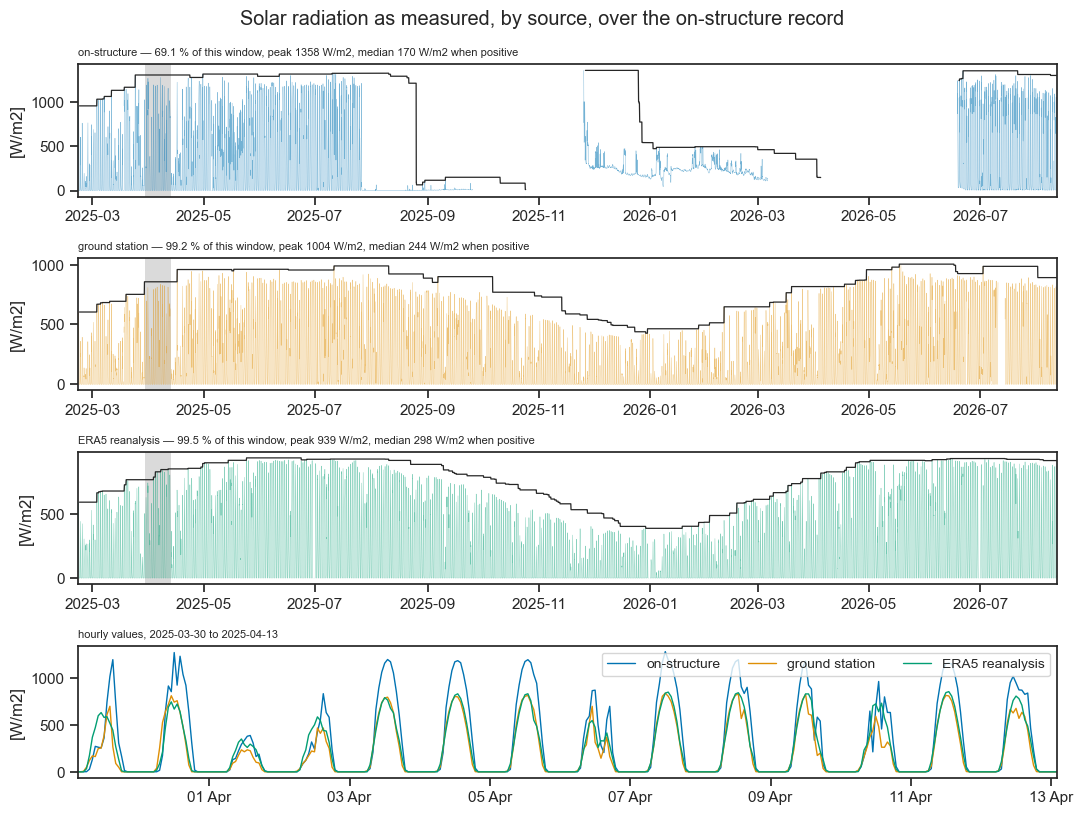

In [7]:
pc.plot_series_by_source(
    df, 'sr', span='overlap',
    title='Solar radiation as measured, by source, over the on-structure record',
    save_path=OUTPUT_DIR, filename='P_F09_radiation_series')
plt.show()

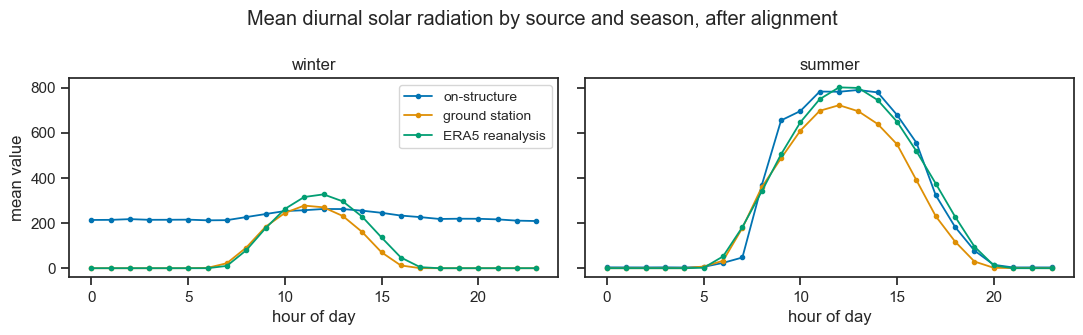

In [8]:
profiles = pc.peak_hour_profile(df, quantity='sr')
pc.plot_clock(
    profiles, evidence=evidence,
    title='Mean diurnal solar radiation by source and season, after alignment',
    save_path=OUTPUT_DIR, filename='P_F01_clock')
plt.show()

## Step 2 · The data dictionary

Generated from the mapping tables in `pc_lib`, so the documentation and the
code cannot drift apart. Every study that consumes these channels reads this
file.

In [9]:
DEFECT_NOTES = {
    'sr_str': 'Reads roughly 60 W/m2 at midnight and places solar noon after '
              'its own temperature maximum. Exists only from 2025-02-21. '
              'Not usable as a clock reference.',
    'rain_gs': 'Carries at least one corrupt value of order 1e9 mm.',
    'rh_gs': 'Minimum of 1 %, which is unlikely at this site and may be a '
             'dropout rather than a reading.',
    'twall_str': 'Present on about a third of the current era; the -55 probe '
                 'failure sentinel covers the rest.',
}
extents = {s: f'{inventory[inventory["source"] == s]["first"].min()[:10]} to '
              f'{inventory[inventory["source"] == s]["last"].max()[:10]}'
           for s in pc.SOURCES}

written = pc.write_data_dictionary(DICT_PATH, report=inventory,
                                   extents=extents, notes=DEFECT_NOTES)
print(f'data dictionary written to {written}')

comparable = pd.DataFrame([
    {'quantity': q,
     'sources': ', '.join(s for s in pc.SOURCES
                          if f'{q}_{s}' in df.columns),
     'overlap_days': round(
         df[[f'{q}_{s}' for s in pc.SOURCES
             if f'{q}_{s}' in df.columns]].dropna().shape[0] / 24.0, 1)}
    for q in pc.QUANTITY_UNIT
    if any(f'{q}_{s}' in df.columns for s in pc.SOURCES)
]).set_index('quantity')
display(comparable)
comparable.to_csv(f'{OUTPUT_DIR}/P_03_comparable_channels.csv')

data dictionary written to ../../docs/proxy-data-dictionary.md


,sources,overlap_days
quantity,,
tair,"str, gs, era5",1945.3
rh,"str, gs, era5",1913.3
sr,"str, gs, era5",364.0
tdew,"gs, era5",2772.0
pres,gs,2754.9
wspd,"gs, era5",2760.1
rain,"gs, era5",2774.5
twall,str,198.0
tskin,era5,3128.8


## Step 3 · Absolute agreement

Three complementary views, because they answer different questions. Bias and
RMSE say how large the disagreement is. The regression slope and intercept say
what *kind* it is — a slope near one with a non-zero intercept is an offset, a
slope away from one is a scale error, and they call for different remedies. The
limits of agreement say how far a single substituted value might fall from the
one it replaces.

In [10]:
agreement = pd.concat([pc.pairwise_agreement(df, q, min_days=MIN_OVERLAP_DAYS,
                                             dt_hours=SAMPLING_HOURS)
                       for q in QUANTITIES], ignore_index=True)
display(agreement)
agreement.to_csv(f'{OUTPUT_DIR}/P_04_pairwise_agreement.csv', index=False)

assert (agreement['overlap_days'] >= MIN_OVERLAP_DAYS).all(), \
    'overlap guard: a statistic was reported on too little data'

,quantity,reference,compared,n,overlap_days,bias,MAE,RMSE,sd_of_diff,slope,intercept,r,loa_lower,loa_upper
0,tair,str,gs,47002,1958.4,0.367,1.121,1.398,1.349,0.9419,1.164,0.9882,-2.278,3.011
1,tair,str,era5,49147,2047.8,-0.566,1.527,1.922,1.837,0.9215,0.527,0.9777,-4.166,3.033
2,tair,gs,era5,66517,2771.5,-0.924,1.357,1.808,1.554,0.9693,-0.474,0.9813,-3.969,2.121
3,rh,str,gs,46234,1926.4,-6.507,8.566,11.871,9.929,0.7746,10.380,0.8803,-25.968,12.953
4,rh,str,era5,49147,2047.8,-1.276,9.408,12.038,11.970,0.6860,22.225,0.8215,-24.737,22.185
5,rh,gs,era5,64565,2690.2,5.799,8.799,12.902,11.526,0.7448,22.908,0.8057,-16.791,28.390
6,sr,str,gs,8824,367.7,-67.045,153.921,233.045,223.206,0.5769,35.947,0.7442,-504.528,370.439
7,sr,str,era5,8839,368.3,-43.109,153.076,231.710,227.677,0.6055,53.208,0.7380,-489.356,403.139
8,sr,gs,era5,66576,2774.0,29.122,47.361,97.037,92.564,0.9984,29.357,0.9300,-152.304,210.548


In [11]:
breakdowns = {}
for q in QUANTITIES:
    for compared in ('gs', 'era5'):
        if f'{q}_{compared}' not in df.columns:
            continue
        for by in ('season', 'hour'):
            key = f'{q}·{compared}·{by}'
            table = pc.agreement_breakdown(df, q, reference='str',
                                           compared=compared, by=by)
            if len(table):
                breakdowns[key] = table

print('Air temperature, on-structure against each proxy, by season:')
for compared in ('gs', 'era5'):
    key = f'tair·{compared}·season'
    if key in breakdowns:
        print(f'\n  {pc.SOURCE_LABEL[compared]}')
        display(breakdowns[key])

pd.concat(breakdowns, names=['comparison']).to_csv(
    f'{OUTPUT_DIR}/P_05_agreement_breakdown.csv')

Air temperature, on-structure against each proxy, by season:

  ground station


,n,bias,MAE,sd
group,,,,
DJF,13968,0.945,1.251,1.092
JJA,11462,-0.404,1.136,1.469
MAM,10329,0.562,1.034,1.178
SON,11243,0.253,1.024,1.259



  ERA5 reanalysis


,n,bias,MAE,sd
group,,,,
DJF,14197,0.017,1.328,1.656
JJA,12275,-1.592,1.954,1.801
MAM,10553,-0.234,1.388,1.732
SON,12122,-0.501,1.448,1.734


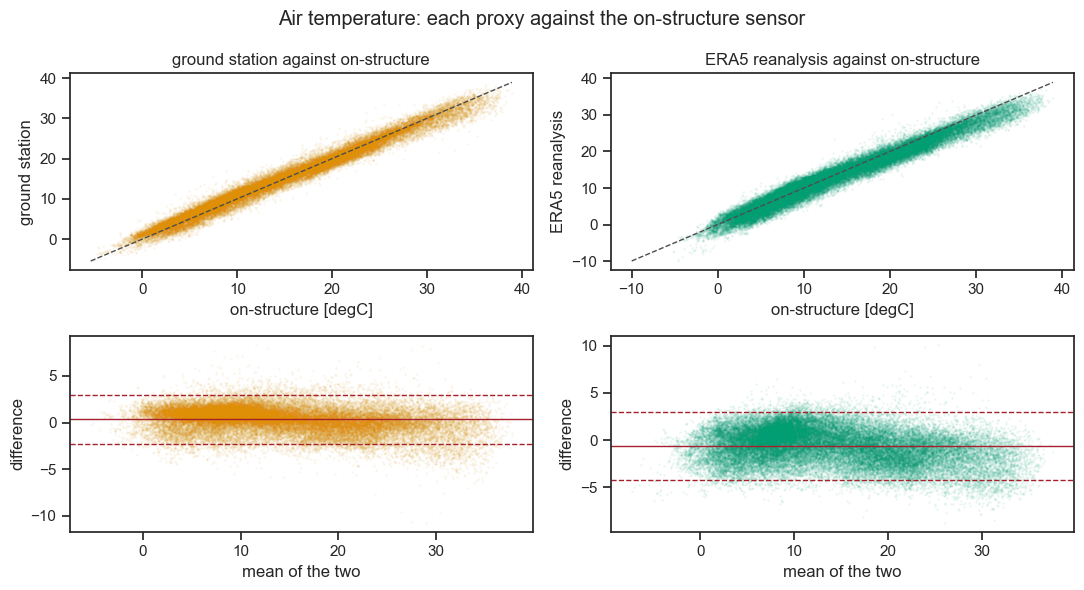

In [12]:
pc.plot_agreement(
    df, 'tair',
    title='Air temperature: each proxy against the on-structure sensor',
    save_path=OUTPUT_DIR, filename='P_F02_agreement_tair')
plt.show()

## Step 4 · Dynamic agreement

A proxy can sit two degrees low and still drive the wall correctly, or match on
average and miss every daily swing. Amplitude, phase and first-difference
agreement separate those cases.

In [13]:
diurnal = pd.concat({q: pc.diurnal_comparison(df, q) for q in QUANTITIES},
                    names=['quantity'])
display(diurnal)
diurnal.to_csv(f'{OUTPUT_DIR}/P_06_diurnal_comparison.csv')

n     mean  diurnal_amplitude  peak_hour  trough_hour  daily_amplitude  amplitude_ratio
quantity source                                                                                             
tair     str     49463   13.932              3.308         13            6            8.020            1.000
         gs      66906   14.658              3.801         13            5            8.932            1.149
         era5    75091   13.716              3.937         14            5            8.959            1.190
rh       str     49463   74.797             10.224          7           14           28.948            1.000
         gs      64954   66.994             11.871          6           14           31.317            1.161
         era5    75091   73.379             13.912          5           14           34.131            1.361
sr       str      8929  244.663            260.987         12           23          628.607            1.000
         gs      66966  147.054            243.045         12            1          553.598            0.931
         era5    75091  176.380            282.585         12            2          585.973            1.083

In [14]:
differences = pd.concat([pc.difference_agreement(df, q,
                                                 min_days=MIN_OVERLAP_DAYS,
                                                 dt_hours=SAMPLING_HOURS)
                         for q in QUANTITIES], ignore_index=True)
display(differences[['quantity', 'reference', 'compared', 'n', 'r', 'RMSE',
                     'slope', 'bias']])
differences.to_csv(f'{OUTPUT_DIR}/P_07_difference_agreement.csv', index=False)

level_r = agreement.set_index(['quantity', 'reference', 'compared'])['r']
diff_r = differences.set_index(['quantity', 'reference', 'compared'])['r']
comparison = pd.DataFrame({'r_levels': level_r, 'r_differences': diff_r})
comparison['drop'] = (comparison['r_levels']
                      - comparison['r_differences']).round(4)
print('\nHow much agreement is lost moving from levels to differences:')
display(comparison)

,quantity,reference,compared,n,r,RMSE,slope,bias
0,tair,str,gs,46121,0.6987,0.865,0.6843,0.001
1,tair,str,era5,48567,0.6900,0.864,0.6386,0.001
2,tair,gs,era5,66003,0.7307,0.803,0.6791,-0.001
3,rh,str,gs,45275,0.5458,4.201,0.5415,-0.011
4,rh,str,era5,48567,0.4889,4.512,0.4983,0.000
5,rh,gs,era5,63888,0.4593,4.693,0.4544,0.021
6,sr,str,gs,8798,0.4911,131.237,0.3426,0.482
7,sr,str,era5,8819,0.4889,128.956,0.2835,0.418
8,sr,gs,era5,66086,0.6479,75.342,0.5371,-0.015



How much agreement is lost moving from levels to differences:


r_levels  r_differences    drop
quantity reference compared                                 
tair     str       gs          0.9882         0.6987  0.2895
                   era5        0.9777         0.6900  0.2877
         gs        era5        0.9813         0.7307  0.2506
rh       str       gs          0.8803         0.5458  0.3345
                   era5        0.8215         0.4889  0.3326
         gs        era5        0.8057         0.4593  0.3464
sr       str       gs          0.7442         0.4911  0.2531
                   era5        0.7380         0.4889  0.2491
         gs        era5        0.9300         0.6479  0.2821

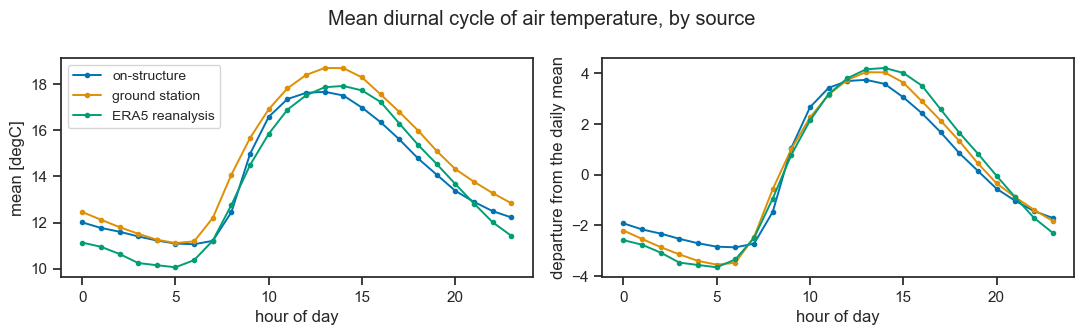

In [15]:
pc.plot_diurnal_profiles(
    df, 'tair',
    title='Mean diurnal cycle of air temperature, by source',
    save_path=OUTPUT_DIR, filename='P_F03_diurnal_tair')
plt.show()

### Solar radiation, over the daylight hours alone

Roughly half of every radiation record is a structural night-time zero. Those
zeros are real measurements and are never removed, but they distort every
statistic computed over the whole day: the correlation is inflated by a large
block of samples on which all three sources trivially agree, the limits of
agreement are computed over a bimodal distribution, and the trough hour of the
mean diurnal cycle is an arbitrary point inside the night — the all-hours
table above reports 23, 1 and 2 for the three sources, which are not findings.

The mask is geometric: the sun's elevation above the horizon, computed from
the site coordinates alone. It is therefore independent of all three sources,
it is defined at timestamps where a radiation sensor is missing, and the same
mask applies to every channel so none of them helps define it. It takes no
account of cloud or of the local horizon formed by the surrounding terrain.

These figures are reported **beside** the all-hours figures, never in place of
them.

### Parameter Tuning Guidance

| Parameter | Purpose | Default | Effect |
|---|---|---|---|
| `MIN_ELEVATION` | Solar elevation above which an hour counts as daylight | `0.0` | Raising it to 5–10 degrees drops the shallow-sun hours near sunrise and sunset, where a wall's self-shading and the terrain horizon matter most; it also shortens the usable day and reduces `n`. |

In [16]:
MIN_ELEVATION = 0.0

daylight = pc.daylight_mask(df.index, min_elevation=MIN_ELEVATION)
df_day = df.loc[daylight]
print(f'daylight hours: {int(daylight.sum())} of {len(daylight)} '
      f'({100.0 * daylight.mean():.1f} %)')

daylight_agreement = pc.pairwise_agreement(
    df_day, 'sr', min_days=MIN_OVERLAP_DAYS, dt_hours=SAMPLING_HOURS)
daylight_differences = pc.difference_agreement(
    df_day, 'sr', min_days=MIN_OVERLAP_DAYS, dt_hours=SAMPLING_HOURS)
daylight_diurnal = pc.diurnal_comparison(df_day, 'sr')

all_hours = agreement[agreement['quantity'] == 'sr'].set_index(
    ['reference', 'compared'])
day_hours = daylight_agreement.set_index(['reference', 'compared'])
contrast = pd.DataFrame({
    'r_all_hours': all_hours['r'],
    'r_daylight': day_hours['r'],
    'MAE_all_hours': all_hours['MAE'],
    'MAE_daylight': day_hours['MAE'],
})
print('\nSolar radiation, all hours against daylight only:')
display(contrast)

pd.concat({'agreement': daylight_agreement.set_index(['reference', 'compared']),
           'differences': daylight_differences.set_index(['reference',
                                                          'compared'])},
          names=['statistic']).to_csv(
    f'{OUTPUT_DIR}/P_21_sr_daylight_agreement.csv')
daylight_diurnal.to_csv(f'{OUTPUT_DIR}/P_21b_sr_daylight_diurnal.csv')

assert 0.40 < float(daylight.mean()) < 0.60, \
    'daylight guard: the mask does not select roughly half the record'
print('\nDaylight guard passed.')

daylight hours: 38097 of 75505 (50.5 %)

Solar radiation, all hours against daylight only:


r_all_hours  r_daylight  MAE_all_hours  MAE_daylight
reference compared                                                      
str       gs             0.7442      0.7049        153.921       211.523
          era5           0.7380      0.6998        153.076       210.934
gs        era5           0.9300      0.8863         47.361        90.040


Daylight guard passed.


## Step 5 · Relationship with the inclination

Each source against the one target, in levels and in first differences.

The first difference is the quantity with a meaning independent of how the
record was assembled: the instrument's installation offset, the compensation
anchor and the levelling correction all cancel under differencing. The level
comparison is reported beside it and carries every one of those constants.

The slope is a description of the residual response that survives the
calibration. **It is not a candidate compensation coefficient** — the
coefficient is the manufacturer's and is not re-estimated anywhere in this
project.

In [17]:
relationship = pd.concat([pc.target_relationship(
    df, q, target=TARGET, hac_lags=24, min_days=MIN_OVERLAP_DAYS,
    dt_hours=SAMPLING_HOURS) for q in QUANTITIES], ignore_index=True)
display(relationship)
relationship.to_csv(f'{OUTPUT_DIR}/P_08_target_relationship.csv', index=False)

assert TARGET in df.columns, 'target guard: the calibrated target is missing'
print(f'\nTarget guard passed: every relationship is measured against '
      f'{TARGET}, unmodified.')

,quantity,source,domain,n,overlap_days,r,slope_mdeg_per_unit,slope_se,t,r2
0,tair,str,levels,49463,2061.0,-0.5238,-4.9013,0.1719,-28.51,0.2743
1,tair,str,differences,48893,2037.2,-0.1545,-3.7635,0.2000,-18.82,0.0239
2,tair,gs,levels,47002,1958.4,-0.4764,-4.6750,0.1871,-24.99,0.2269
3,tair,gs,differences,46121,1921.7,-0.0913,-2.2277,0.0929,-23.98,0.0083
4,tair,era5,levels,49147,2047.8,-0.5061,-5.0267,0.1774,-28.34,0.2561
5,tair,era5,differences,48567,2023.6,-0.0842,-2.2117,0.0897,-24.66,0.0071
6,rh,str,levels,49463,2061.0,0.2277,0.8772,0.0722,12.15,0.0518
7,rh,str,differences,48893,2037.2,0.1078,0.6745,0.0322,20.95,0.0116
8,rh,gs,levels,46234,1926.4,0.1930,0.8432,0.0814,10.36,0.0372
9,rh,gs,differences,45275,1886.5,0.0669,0.4134,0.0219,18.88,0.0045



Target guard passed: every relationship is measured against inc_comp, unmodified.


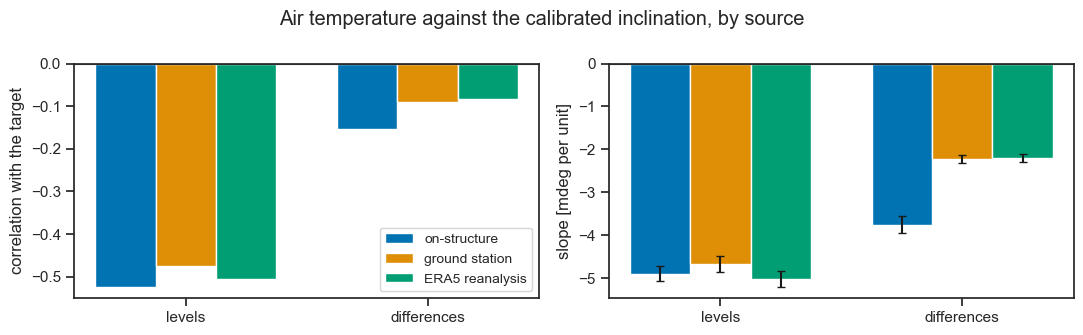

In [18]:
pc.plot_target_relationship(
    relationship[relationship['quantity'] == 'tair'],
    title='Air temperature against the calibrated inclination, by source',
    save_path=OUTPUT_DIR, filename='P_F05_relationship')
plt.show()

In [19]:
slope_table = relationship.pivot_table(
    index=['quantity', 'domain'], columns='source',
    values='slope_mdeg_per_unit')
display(slope_table)
slope_table.to_csv(f'{OUTPUT_DIR}/P_10_slopes.csv')

source                  era5      gs     str
quantity domain                             
rh       differences  0.3968  0.4134  0.6745
         levels       1.1005  0.8432  0.8772
sr       differences -0.0325 -0.0259  0.0382
         levels      -0.0756 -0.0817 -0.0460
tair     differences -2.2117 -2.2277 -3.7635
         levels      -5.0267 -4.6750 -4.9013

## Step 5a · The windows the comparison can actually use

Every statistic above this point is computed on the joined frame, which spans
July 2018 to August 2026, contains both instrument eras, and is ragged. The
sibling studies never correlate against the target on a span of that kind.
They cut contiguous blocks of near-complete coverage, group them into tiers
according to which channels a tier requires, and report every correlation,
slope and operator inside a tier.

The difference is not cosmetic. `inclination_prediction` reports the
calibrated inclination against on-structure air temperature at r = −0.956 in
levels and −0.886 in first differences on its Tier 1 blocks; the pooled
computation in `P_08` above returns −0.524 and −0.155 for the same pair. For
solar radiation the pooled computation reverses the sign outright.

The radiation record settles the shape of the tiers by itself. `sr_str` begins
on 2025-02-21, which is the era boundary, so the three-source radiation
comparison lives entirely inside the current era, and the two proxies
additionally reach into a legacy era the on-structure channel can never enter.

### Parameter Tuning Guidance

| Parameter | Purpose | Default | Effect |
|---|---|---|---|
| `BLOCK_MIN_DAYS` | Shortest block reported | `20` | The sibling studies' value, kept so block inventories are comparable across studies. Raising it discards short usable windows; lowering it admits blocks too short for a seasonal statistic. |
| `BLOCK_MAX_GAP_H` | Longest interruption absorbed into a block | `6` | Short interruptions are bridged because the statistics score only at observed timestamps. Raising it merges genuinely separate windows; lowering it fragments the record. |
| `TIERS` | Which channels each tier requires | see cell | A tier requiring an on-structure channel cannot reach the legacy era. Adding a channel to a tier can only shorten its blocks. |

In [20]:
# The discrepancy with the sibling study is attributed to the analysis window
# only if the two studies are measuring the same target. inclination_prediction
# builds inc_comp through ip.add_target inside its own current-era loader; this
# study takes it from ud.load_unified. The two are compared directly before any
# conclusion rests on the difference.
sensor_raw = ud.load_unified(UNIFIED_DIR, STATION)

sensor_current = sensor_raw.loc[sensor_raw.index >= pc.ERA_BOUNDARY].copy()
try:
    rebuilt = ip.add_target(sensor_current)
    common = df.index.intersection(rebuilt.index)
    delta = (df.loc[common, TARGET] - rebuilt.loc[common, TARGET]).dropna()
except Exception as exc:                                   # noqa: BLE001
    print(f'target check could not run: {type(exc).__name__}: {exc}')
    delta = pd.Series(dtype=float)

if len(delta):
    print(f'target check over {len(delta)} common hours: '
          f'max |difference| {delta.abs().max():.6f} mdeg, '
          f'mean {delta.mean():+.6f} mdeg')
else:
    print('target check: no common hours, the two constructions cannot be '
          'compared on this frame')

TARGET_TOLERANCE_MDEG = 1e-6
targets_identical = bool(len(delta)) and delta.abs().max() < TARGET_TOLERANCE_MDEG
print(f'targets identical: {targets_identical}')

target check over 9964 common hours: max |difference| 0.000000 mdeg, mean -0.000000 mdeg
targets identical: True


### The acquisition-fault register

The current era contains hours in which the inclination moves by hundreds of
millidegrees and returns on the following sample. The cause is neither the
structure nor the compensation. At 2025-05-10 14:00 the raw inclination moves
220 mdeg, the air temperature rises 5.9 °C and the battery voltage dips, all
within the same hour and all recovering at the next. Three physically
independent channels do not fail together for one sample because a wall moved.

The compensated channel inherits the excursion from the raw one and enlarges it
wherever the temperature spiked as well, so differencing the calibrated reading
— which is the right series to difference — neither creates these events nor
escapes them.

They matter because they live almost entirely in the first difference: one
unreversed hour contributes two large differences of opposite sign. An
unscreened current-era first-difference correlation therefore measures the
faults rather than the wall.

The hours are **marked, not deleted**. The register below records the evidence
that justifies every flag, and the mask is applied to the calibrated level, so
the same decision governs the level statistics and the differenced ones rather
than two separate rules.

### Parameter Tuning Guidance

| Parameter | Purpose | Default | Effect |
|---|---|---|---|
| `FAULT_WINDOW` | Width of the centred rolling window used for the local median and MAD | `25` | One day either side of centre on the hourly grid. Narrower tracks the diurnal cycle too closely and hides genuine excursions; wider blurs the seasonal envelope into the reference. |
| `FAULT_K` | Robust z above which an hour is registered | `8.0` | Deliberately conservative. The result is insensitive across 3–8, which is the signature of a genuine outlier population rather than a threshold artefact. |

In [21]:
FAULT_WINDOW = 25
FAULT_K = 8.0

faults = pc.acquisition_faults(sensor_raw, target=TARGET,
                               window=FAULT_WINDOW, k=FAULT_K)
faults.to_csv(f'{OUTPUT_DIR}/P_23_acquisition_faults.csv')

print(f'{len(faults)} hours registered as acquisition faults '
      f'({100.0 * len(faults) / len(sensor_raw):.3f} % of the grid)')
if len(faults):
    display(faults.groupby('era').agg(
        hours=('delta_mdeg', 'size'),
        largest_step_mdeg=('delta_mdeg', lambda s: s.abs().max()),
        corroborated=('n_corroborating', lambda s: int((s > 0).sum())),
        reversing=('reverses_next_hour', 'sum')))
    print('\nThe ten largest, with the evidence behind each flag:')
    display(faults.reindex(
        faults['delta_mdeg'].abs().sort_values(ascending=False).index).head(10))

# Sensitivity: a genuine outlier population is insensitive to the threshold.
sensitivity = pd.DataFrame([
    {'k': k, 'hours_flagged': len(pc.acquisition_faults(
        sensor_raw, target=TARGET, window=FAULT_WINDOW, k=k))}
    for k in (3.0, 5.0, 8.0, 12.0)]).set_index('k')
display(sensitivity)

# The mask is applied to the calibrated level. A level statistic then skips the
# hour and a first difference is never taken across it, so one decision governs
# both domains.
df_screened = pc.mask_faults(df, faults, cols=[TARGET])
print(f'\n{TARGET}: {int(df[TARGET].notna().sum())} hours before screening, '
      f'{int(df_screened[TARGET].notna().sum())} after.')

175 hours registered as acquisition faults (0.248 % of the grid)


,hours,largest_step_mdeg,corroborated,reversing
era,,,,
current,74,1247.13,68,45
legacy,101,31.68,26,36



The ten largest, with the evidence behind each flag:


,era,z_inc_comp,delta_mdeg,n_corroborating,reverses_next_hour
datetime,,,,,
2026-07-18 12:00:00,current,-62.7,-1247.13,1,True
2026-08-04 11:00:00,current,-83.8,-1203.25,1,True
2026-07-10 12:00:00,current,-81.7,-1017.36,1,True
2026-07-22 12:00:00,current,-58.3,-985.93,1,True
2026-07-23 12:00:00,current,-75.4,-875.34,1,True
2026-07-13 12:00:00,current,-56.6,-868.79,1,True
2026-07-03 11:00:00,current,-83.2,-854.13,1,True
2026-07-04 12:00:00,current,-51.6,-833.47,1,True
2026-08-11 10:00:00,current,-27.7,-832.38,1,False


,hours_flagged
k,
3.0,2433
5.0,678
8.0,175
12.0,95



inc_comp: 49463 hours before screening, 49288 after.


In [22]:
BLOCK_MIN_DAYS = 20
BLOCK_MAX_GAP_H = 6

TIERS = {
    'P0': ['inc_comp', 'tair_str', 'sr_str',
           'tair_gs', 'sr_gs', 'tair_era5', 'sr_era5'],
    'P1': ['inc_comp', 'tair_gs', 'sr_gs', 'tair_era5', 'sr_era5'],
    'P2': ['inc_comp', 'tair_gs', 'sr_gs', 'tair_era5', 'sr_era5'],
}

inventory_blocks = pc.tier_blocks(
    df_screened, TIERS, era_boundary=pc.ERA_BOUNDARY,
    min_days=BLOCK_MIN_DAYS, max_gap_hours=BLOCK_MAX_GAP_H)

# P0 and P1 are current-era tiers; P2 is the legacy-era window of the same
# proxy-only channel set. tier_blocks finds blocks in both eras for every tier,
# so each tier is reduced to the era it is defined for.
ERA_OF_TIER = {'P0': 'current', 'P1': 'current', 'P2': 'legacy'}
inventory_blocks = inventory_blocks[
    [ERA_OF_TIER[t] == e
     for t, e in zip(inventory_blocks['tier'], inventory_blocks['era'])]
].reset_index(drop=True)

display(inventory_blocks)
inventory_blocks.to_csv(f'{OUTPUT_DIR}/P_13_block_inventory.csv', index=False)

TIER_LABEL = {
    'P0': 'all three sources, current era',
    'P1': 'proxies only, current era',
    'P2': 'proxies only, legacy era',
}
for tier in TIERS:
    rows = inventory_blocks[inventory_blocks['tier'] == tier]
    longest = rows['days'].max() if len(rows) else 0.0
    print(f'{tier} ({TIER_LABEL[tier]}): {len(rows)} block(s), '
          f'{rows["days"].sum():.1f} days total, longest {longest:.1f} days')

for tier in TIERS:
    rows = inventory_blocks[inventory_blocks['tier'] == tier]
    assert len(rows) and rows['days'].max() >= MIN_OVERLAP_DAYS, \
        f'tier guard: {tier} has no block of at least {MIN_OVERLAP_DAYS} days'
print(f'\nTier guard passed: every tier holds a block of at least '
      f'{MIN_OVERLAP_DAYS} days.')

for _, row in inventory_blocks.iterrows():
    if row['era'] == 'legacy':
        assert row['end'] < pc.ERA_BOUNDARY, \
            f'{row["block"]} crosses the era boundary'
    else:
        assert row['start'] >= pc.ERA_BOUNDARY, \
            f'{row["block"]} crosses the era boundary'
print('Era guard passed: no block spans the 2025-02-21 reinstallation.')

,tier,era,block,start,end,days,coverage_%
0,P0,current,P0-cur1,2025-07-01 01:00:00,2025-09-25 16:00:00,86.6,99.9
1,P0,current,P0-cur2,2025-02-21 00:00:00,2025-05-05 03:00:00,73.1,99.1
2,P0,current,P0-cur3,2025-05-05 11:00:00,2025-06-30 01:00:00,55.6,99.9
3,P0,current,P0-cur4,2025-11-25 11:00:00,2025-12-31 00:00:00,35.5,100.0
4,P0,current,P0-cur5,2026-01-01 00:00:00,2026-02-02 01:00:00,32.0,99.1
5,P0,current,P0-cur6,2026-02-02 09:00:00,2026-03-06 09:00:00,32.0,99.5
6,P0,current,P0-cur7,2026-07-14 14:00:00,2026-08-12 01:00:00,28.5,95.2
7,P1,current,P1-cur1,2025-07-01 01:00:00,2025-09-25 16:00:00,86.6,99.9
8,P1,current,P1-cur2,2025-10-13 11:00:00,2025-12-31 00:00:00,78.5,99.6
9,P1,current,P1-cur3,2025-02-21 00:00:00,2025-05-05 03:00:00,73.1,99.3


P0 (all three sources, current era): 7 block(s), 343.3 days total, longest 86.6 days
P1 (proxies only, current era): 7 block(s), 386.3 days total, longest 86.6 days
P2 (proxies only, legacy era): 23 block(s), 1269.4 days total, longest 107.8 days

Tier guard passed: every tier holds a block of at least 30 days.
Era guard passed: no block spans the 2025-02-21 reinstallation.


## Step 5b · Correlation structure, per tier

The correlation matrix over the target and every source channel the tier
carries, computed twice: on levels and on first differences.

Correlations between two trending series are inflated by the shared trend and
say little about a driver-response relationship. The differenced matrix is the
honest one for a signal with drift. Both are reported so the gap between them
is visible, which is the convention the sibling studies use.

Differences are taken **inside each block** and concatenated. A difference
across a block boundary would manufacture a step out of a gap.

In [23]:
CHANNEL_ORDER = ['inc_comp',
                 'tair_str', 'tair_gs', 'tair_era5',
                 'sr_str', 'sr_gs', 'sr_era5']

corr_levels, corr_differences, tier_channels = {}, {}, {}
for tier in TIERS:
    frame = pc.tier_frame(df_screened, inventory_blocks, tier)
    cols = [c for c in CHANNEL_ORDER
            if c in frame.columns and frame[c].notna().any()]
    tier_channels[tier] = cols

    corr_levels[tier] = frame[cols].corr()
    corr_differences[tier] = pc.tier_differences(
        df_screened, inventory_blocks, tier, cols=cols).corr()

    print(f'\n{tier} ({TIER_LABEL[tier]}) — {len(cols)} channels, '
          f'{len(frame)} hourly slots')
    print('  against the target, levels:      ', ', '.join(
        f'{c} {corr_levels[tier].loc["inc_comp", c]:+.3f}'
        for c in cols if c != 'inc_comp'))
    print('  against the target, differences: ', ', '.join(
        f'{c} {corr_differences[tier].loc["inc_comp", c]:+.3f}'
        for c in cols if c != 'inc_comp'))

pd.concat(corr_levels, names=['tier']).to_csv(
    f'{OUTPUT_DIR}/P_14_corr_levels.csv')
pd.concat(corr_differences, names=['tier']).to_csv(
    f'{OUTPUT_DIR}/P_15_corr_differences.csv')


P0 (all three sources, current era) — 7 channels, 8248 hourly slots
  against the target, levels:       tair_str -0.953, tair_gs -0.940, tair_era5 -0.932, sr_str -0.142, sr_gs -0.442, sr_era5 -0.460
  against the target, differences:  tair_str -0.840, tair_gs -0.582, tair_era5 -0.570, sr_str -0.533, sr_gs -0.430, sr_era5 -0.527

P1 (proxies only, current era) — 7 channels, 9280 hourly slots
  against the target, levels:       tair_str -0.952, tair_gs -0.938, tair_era5 -0.929, sr_str -0.142, sr_gs -0.444, sr_era5 -0.465
  against the target, differences:  tair_str -0.842, tair_gs -0.583, tair_era5 -0.570, sr_str -0.533, sr_gs -0.432, sr_era5 -0.529

P2 (proxies only, legacy era) — 6 channels, 30485 hourly slots
  against the target, levels:       tair_str -0.541, tair_gs -0.543, tair_era5 -0.539, sr_gs -0.222, sr_era5 -0.215
  against the target, differences:  tair_str -0.890, tair_gs -0.668, tair_era5 -0.569, sr_gs -0.491, sr_era5 -0.580


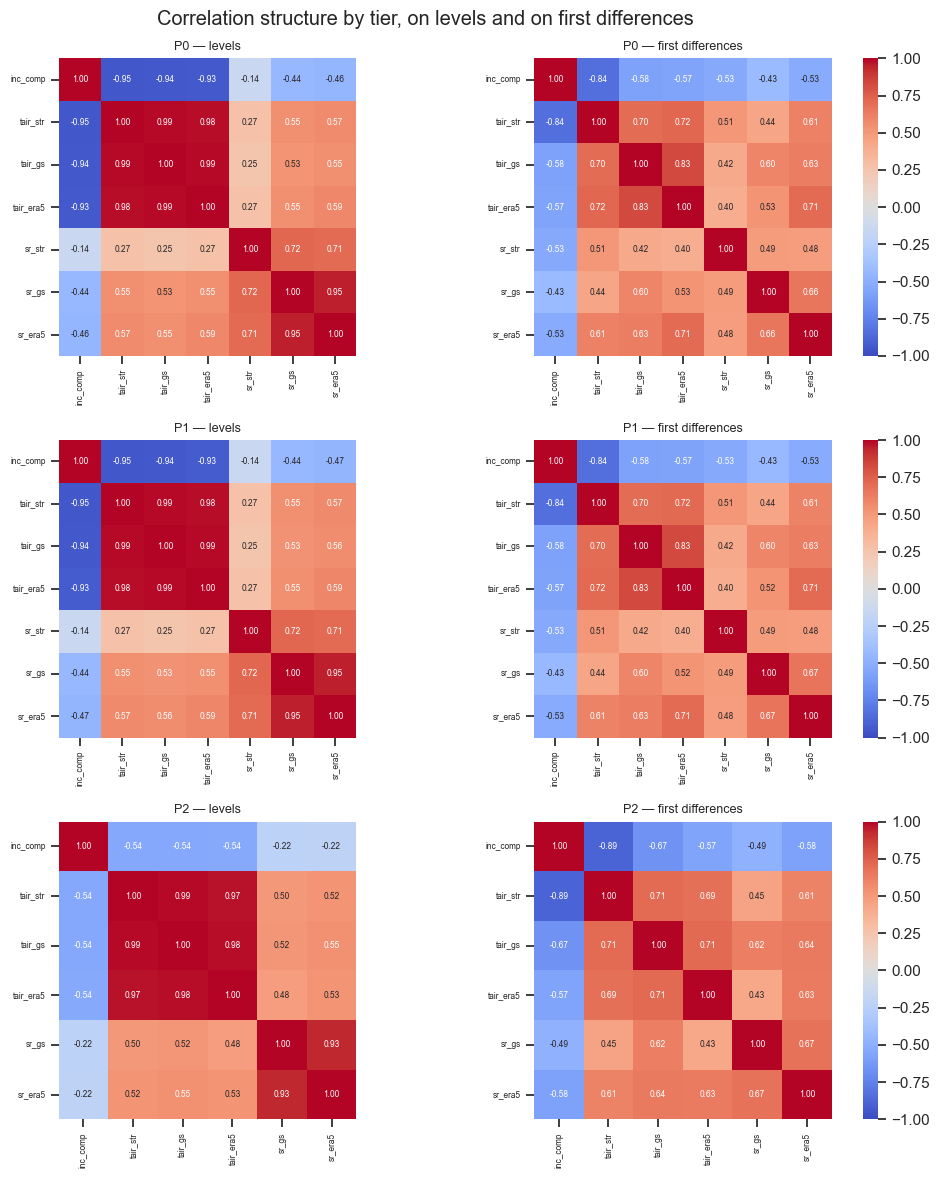

In [24]:
fig, axes = plt.subplots(len(TIERS), 2,
                         figsize=pc.figsize(11, 4.0 * len(TIERS)),
                         squeeze=False)
for row, tier in enumerate(TIERS):
    for col, (matrix, label) in enumerate(
            ((corr_levels[tier], 'levels'),
             (corr_differences[tier], 'first differences'))):
        ax = axes[row][col]
        sns.heatmap(matrix, ax=ax, vmin=-1.0, vmax=1.0, cmap='coolwarm',
                    annot=True, fmt='.2f', annot_kws={'size': 6},
                    cbar=(col == 1), square=True)
        ax.set_title(f'{tier} — {label}', fontsize=9)
        ax.tick_params(labelsize=6)
fig.suptitle('Correlation structure by tier, on levels and on first differences')
fig.tight_layout()
pc._finish(fig, save_path=OUTPUT_DIR, filename='P_F06_correlations')
plt.show()

## Step 5c · Relationship with the inclination, per tier

Each source against the one target, in levels and in first differences, inside
each tier's blocks. The slope describes the residual response that survives
the calibration. **It is not a candidate compensation coefficient** — the
coefficient is the manufacturer's and is not re-estimated anywhere in this
project.

Relative humidity is reported here where it is present, but it never defines a
tier: the tiers are cut on air temperature and solar radiation, which are the
quantities this section analyses and the ones whose availability constrains
the windows.

Standard errors are Newey–West at 24 lags, because the residuals of an hourly
thermal regression are strongly autocorrelated and ordinary standard errors
would be far too small.

In [25]:
# Both the screened and the unscreened frame are reported. The screened
# figures are the ones the study stands behind; the unscreened ones are kept
# beside them so the size of the correction is visible rather than asserted.
parts = []
for label, frame in (('screened', df_screened), ('raw', df)):
    block = pd.concat(
        [pc.target_relationship(frame, q, target=TARGET, hac_lags=24,
                                min_days=MIN_OVERLAP_DAYS,
                                dt_hours=SAMPLING_HOURS,
                                blocks=inventory_blocks, tier=tier)
         for tier in TIERS for q in QUANTITIES],
        ignore_index=True)
    block.insert(1, 'screening', label)
    parts.append(block)
relationship_all = pd.concat(parts, ignore_index=True)
relationship_tiers = relationship_all[
    relationship_all['screening'] == 'screened'].reset_index(drop=True)

display(relationship_tiers)
relationship_all.to_csv(f'{OUTPUT_DIR}/P_16_target_relationship_tiers.csv',
                        index=False)

# What the fault register changes, at fixed tier and domain.
key = ['tier', 'quantity', 'source', 'domain']
screening_effect = relationship_all.pivot_table(
    index=key, columns='screening', values='r')
screening_effect['change'] = (screening_effect['screened']
                              - screening_effect['raw']).round(4)
print('\nWhat registering the acquisition faults changes:')
display(screening_effect.loc[
    screening_effect.index.get_level_values('quantity').isin(['tair', 'sr'])])

pooled_r = relationship.set_index(['quantity', 'source', 'domain'])['r']
tier_p0_r = relationship_tiers[relationship_tiers['tier'] == 'P0'].set_index(
    ['quantity', 'source', 'domain'])['r']
contrast_tiers = pd.DataFrame({'r_pooled_span': pooled_r,
                               'r_tier_P0': tier_p0_r}).dropna()
contrast_tiers['change'] = (contrast_tiers['r_tier_P0']
                            - contrast_tiers['r_pooled_span']).round(4)
print('\nWhat the pooled span cost, tier P0 against the whole record:')
display(contrast_tiers)

assert TARGET in df.columns, 'target guard: the calibrated target is missing'
print(f'\nTarget guard passed: every relationship is measured against '
      f'{TARGET}, unmodified.')

,quantity,screening,tier,source,domain,n,overlap_days,r,slope_mdeg_per_unit,slope_se,t,r2
0,tair,screened,P0,str,levels,8196,341.5,-0.9525,-4.6018,0.0670,-68.68,0.9073
1,tair,screened,P0,str,differences,8159,340.0,-0.8403,-3.0102,0.0412,-73.06,0.7061
2,tair,screened,P0,gs,levels,8188,341.2,-0.9396,-4.8416,0.0740,-65.43,0.8828
3,tair,screened,P0,gs,differences,8145,339.4,-0.5824,-2.3907,0.0500,-47.81,0.3392
4,tair,screened,P0,era5,levels,8196,341.5,-0.9319,-4.7661,0.0741,-64.32,0.8684
5,tair,screened,P0,era5,differences,8159,340.0,-0.5698,-2.3362,0.0511,-45.72,0.3247
6,rh,screened,P0,str,levels,8196,341.5,0.6980,1.4642,0.0625,23.43,0.4871
7,rh,screened,P0,str,differences,8159,340.0,0.6543,0.6126,0.0151,40.57,0.4281
8,rh,screened,P0,gs,levels,8159,340.0,0.6403,1.6125,0.0749,21.53,0.4100
9,rh,screened,P0,gs,differences,8112,338.0,0.4918,0.5114,0.0153,33.42,0.2419



What registering the acquisition faults changes:


screening                            raw  screened  change
tier quantity source domain                               
P0   sr       era5   differences -0.0768   -0.5272 -0.4504
                     levels      -0.4105   -0.4597 -0.0492
              gs     differences -0.0569   -0.4295 -0.3726
                     levels      -0.3999   -0.4415 -0.0416
              str    differences  0.0355   -0.5326 -0.5681
                     levels      -0.1650   -0.1420  0.0230
     tair     era5   differences -0.0761   -0.5698 -0.4937
                     levels      -0.7347   -0.9319 -0.1972
              gs     differences -0.0660   -0.5824 -0.5164
                     levels      -0.7358   -0.9396 -0.2038
              str    differences -0.1475   -0.8403 -0.6928
                     levels      -0.7568   -0.9525 -0.1957
P1   sr       era5   differences -0.0773   -0.5288 -0.4515
                     levels      -0.4150   -0.4651 -0.0501
              gs     differences -0.0576   -0.4317 -0.3741
                     levels      -0.4019   -0.4443 -0.0424
              str    differences  0.0355   -0.5326 -0.5681
                     levels      -0.1650   -0.1420  0.0230
     tair     era5   differences -0.0764   -0.5704 -0.4940
                     levels      -0.7358   -0.9291 -0.1933
              gs     differences -0.0668   -0.5826 -0.5158
                     levels      -0.7383   -0.9383 -0.2000
              str    differences -0.1478   -0.8421 -0.6943
                     levels      -0.7599   -0.9522 -0.1923
P2   sr       era5   differences -0.5792   -0.5800 -0.0008
                     levels      -0.2158   -0.2150  0.0008
              gs     differences -0.4894   -0.4909 -0.0015
                     levels      -0.2229   -0.2223  0.0006
     tair     era5   differences -0.5676   -0.5686 -0.0010
                     levels      -0.5384   -0.5386 -0.0002
              gs     differences -0.6688   -0.6684  0.0004
                     levels      -0.5426   -0.5429 -0.0003
              str    differences -0.8899   -0.8899  0.0000
                     levels      -0.5406   -0.5408 -0.0002


What the pooled span cost, tier P0 against the whole record:


r_pooled_span  r_tier_P0  change
quantity source domain                                       
tair     str    levels             -0.5238    -0.9525 -0.4287
                differences        -0.1545    -0.8403 -0.6858
         gs     levels             -0.4764    -0.9396 -0.4632
                differences        -0.0913    -0.5824 -0.4911
         era5   levels             -0.5061    -0.9319 -0.4258
                differences        -0.0842    -0.5698 -0.4856
rh       str    levels              0.2277     0.6980  0.4703
                differences         0.1078     0.6543  0.5465
         gs     levels              0.1930     0.6403  0.4473
                differences         0.0669     0.4918  0.4249
         era5   levels              0.2388     0.6608  0.4220
                differences         0.0648     0.4357  0.3709
sr       str    levels             -0.2149    -0.1420  0.0729
                differences         0.0872    -0.5326 -0.6198
         gs     levels             -0.2326    -0.4415 -0.2089
                differences        -0.0882    -0.4295 -0.3413
         era5   levels             -0.2292    -0.4597 -0.2305
                differences        -0.0913    -0.5272 -0.4359


Target guard passed: every relationship is measured against inc_comp, unmodified.


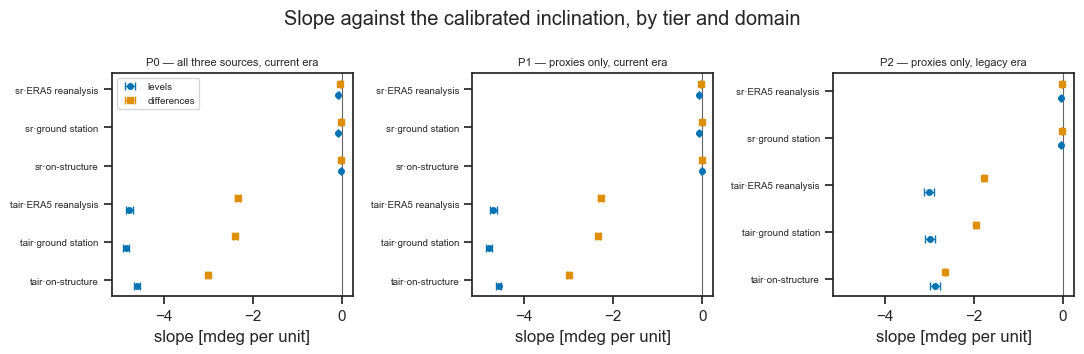

In [26]:
fig, axes = plt.subplots(1, len(TIERS), figsize=pc.figsize(11, 3.6),
                         squeeze=False, sharex=True)
for ax, tier in zip(axes[0], TIERS):
    subset = relationship_tiers[
        (relationship_tiers['tier'] == tier)
        & (relationship_tiers['quantity'].isin(['tair', 'sr']))]
    labels = []
    for offset, (domain, marker) in zip((-0.15, 0.15),
                                        (('levels', 'o'),
                                         ('differences', 's'))):
        rows = subset[subset['domain'] == domain].reset_index(drop=True)
        if not len(rows):
            continue
        positions = np.arange(len(rows)) + offset
        ax.errorbar(rows['slope_mdeg_per_unit'], positions,
                    xerr=rows['slope_se'], fmt=marker, capsize=3,
                    label=domain, lw=0.9, ms=4)
        labels = [f'{q}·{pc.SOURCE_LABEL[s]}'
                  for q, s in zip(rows['quantity'], rows['source'])]
    if labels:
        ax.set_yticks(np.arange(len(labels)))
        ax.set_yticklabels(labels, fontsize=7)
    ax.axvline(0.0, color='0.4', lw=0.8)
    ax.set_title(f'{tier} — {TIER_LABEL[tier]}', fontsize=8)
    ax.set_xlabel('slope [mdeg per unit]')
axes[0][0].legend(fontsize=7)
fig.suptitle('Slope against the calibrated inclination, by tier and domain')
fig.tight_layout()
pc._finish(fig, save_path=OUTPUT_DIR, filename='P_F07_relationship_tiers')
plt.show()

## Step 5d · Transport delay and thermal inertia, on two bands

Before a driver is compared it is given the chance to act through the operator
that suits it. Two are scanned jointly, because scanning either alone can
attribute to one what belongs to the other: a **transport delay** shifts the
driver in time without changing its shape, and a **thermal inertia** low-passes
it through a single-pole filter. The instantaneous case stays in the grid and
competes rather than being assumed away.

The scan is run twice, on the series as they are and on the diurnal band alone
with a one-week centred rolling mean removed. `inclination_prediction` found
that this matters: on the full band, solar radiation's optimum pins at the last
time constant in the grid, 168 hours, lifting explained variance from 0.229 to
0.662. A time constant of one week is not a thermal property of masonry; it is
the width of filter needed to turn a daily radiation cycle into a seasonal
envelope. The diurnal-band operators are the ones carried forward.

Delays are bounded at twelve hours per `docs/raw-data-format.md` §7.5. Air
temperature and solar radiation are external forcings, and beyond half a
diurnal cycle a delay is indistinguishable from a lead.

**The scan runs on each tier's longest single block, not on the union.** A
delay is applied with a shift, a time constant with a recursive filter, and the
band limit with a rolling mean; all three read across adjacent rows, so a union
would let a filter draw values from the far side of a months-long gap.

In [27]:
operator_rows, operator_scans = [], {}
for tier in TIERS:
    block = pc.longest_block(inventory_blocks, tier)
    if block is None:
        continue
    window = df_screened.loc[block['start']:block['end']]
    drivers = [c for c in CHANNEL_ORDER
               if c != TARGET and c in window.columns
               and window[c].notna().sum() > 100]

    for band, detrend in (('full', None), ('diurnal', DETREND_HOURS)):
        summary, scans = ip.operator_table(
            window, TARGET, drivers, delays=DELAYS, taus=TAUS,
            dt_hours=SAMPLING_HOURS, detrend_hours=detrend)
        summary = summary.reset_index()
        summary.insert(0, 'tier', tier)
        summary.insert(1, 'band', band)
        summary.insert(2, 'block', block['block'])
        summary.insert(3, 'block_days', block['days'])
        operator_rows.append(summary)
        if band == 'diurnal':
            operator_scans[tier] = scans

operators_all = pd.concat(operator_rows, ignore_index=True)
operators_fullband = operators_all[operators_all['band'] == 'full']
operators_diurnal = operators_all[operators_all['band'] == 'diurnal']

display(operators_fullband)
display(operators_diurnal)
operators_fullband.to_csv(f'{OUTPUT_DIR}/P_17_operators_fullband.csv',
                          index=False)
operators_diurnal.to_csv(f'{OUTPUT_DIR}/P_18_operators_diurnal.csv',
                         index=False)

boundary_optima = operators_fullband[operators_fullband['tau_h'] >= max(TAUS)]
if len(boundary_optima):
    print('\nFull-band optima sitting at the last time constant in the grid — '
          'these are fitting a component slower than the grid contains:')
    display(boundary_optima[['tier', 'driver', 'tau_h', 'r2',
                             'r2_instantaneous']])

assert operators_diurnal['delay_h'].max() <= MAX_DELAY_H, \
    'delay guard: a diurnal-band optimum exceeds the twelve-hour bound'
print(f'\nDelay guard passed: every diurnal-band optimum sits at or below '
      f'{MAX_DELAY_H} h.')

,tier,band,block,block_days,driver,delay_h,tau_h,r,r2,r2_instantaneous,gain_from_operator
0,P0,full,P0-cur1,86.6,tair_str,0.0,0.0,-0.9389,0.8816,0.8816,0.0000
1,P0,full,P0-cur1,86.6,tair_gs,0.0,0.0,-0.9045,0.8181,0.8181,0.0000
2,P0,full,P0-cur1,86.6,tair_era5,0.0,0.0,-0.8865,0.7860,0.7860,0.0000
3,P0,full,P0-cur1,86.6,sr_str,0.0,1.0,-0.5067,0.2568,0.2382,0.0186
4,P0,full,P0-cur1,86.6,sr_gs,0.0,2.0,-0.7230,0.5227,0.4136,0.1091
5,P0,full,P0-cur1,86.6,sr_era5,0.0,2.0,-0.7085,0.5020,0.4431,0.0589
12,P1,full,P1-cur1,86.6,tair_str,0.0,0.0,-0.9389,0.8816,0.8816,0.0000
13,P1,full,P1-cur1,86.6,tair_gs,0.0,0.0,-0.9045,0.8181,0.8181,0.0000
14,P1,full,P1-cur1,86.6,tair_era5,0.0,0.0,-0.8865,0.7860,0.7860,0.0000
15,P1,full,P1-cur1,86.6,sr_str,0.0,1.0,-0.5067,0.2568,0.2382,0.0186


,tier,band,block,block_days,driver,delay_h,tau_h,r,r2,r2_instantaneous,gain_from_operator
6,P0,diurnal,P0-cur1,86.6,tair_str,0.0,0.0,-0.9771,0.9547,0.9547,0.0000
7,P0,diurnal,P0-cur1,86.6,tair_gs,0.0,0.0,-0.9298,0.8645,0.8645,0.0000
8,P0,diurnal,P0-cur1,86.6,tair_era5,0.0,0.0,-0.9161,0.8393,0.8393,0.0000
9,P0,diurnal,P0-cur1,86.6,sr_str,0.0,1.0,-0.5424,0.2942,0.2619,0.0323
10,P0,diurnal,P0-cur1,86.6,sr_gs,0.0,2.0,-0.8413,0.7078,0.5701,0.1377
11,P0,diurnal,P0-cur1,86.6,sr_era5,0.0,1.0,-0.8285,0.6863,0.6179,0.0685
18,P1,diurnal,P1-cur1,86.6,tair_str,0.0,0.0,-0.9771,0.9547,0.9547,0.0000
19,P1,diurnal,P1-cur1,86.6,tair_gs,0.0,0.0,-0.9298,0.8645,0.8645,0.0000
20,P1,diurnal,P1-cur1,86.6,tair_era5,0.0,0.0,-0.9161,0.8393,0.8393,0.0000
21,P1,diurnal,P1-cur1,86.6,sr_str,0.0,1.0,-0.5424,0.2942,0.2619,0.0323



Delay guard passed: every diurnal-band optimum sits at or below 12 h.


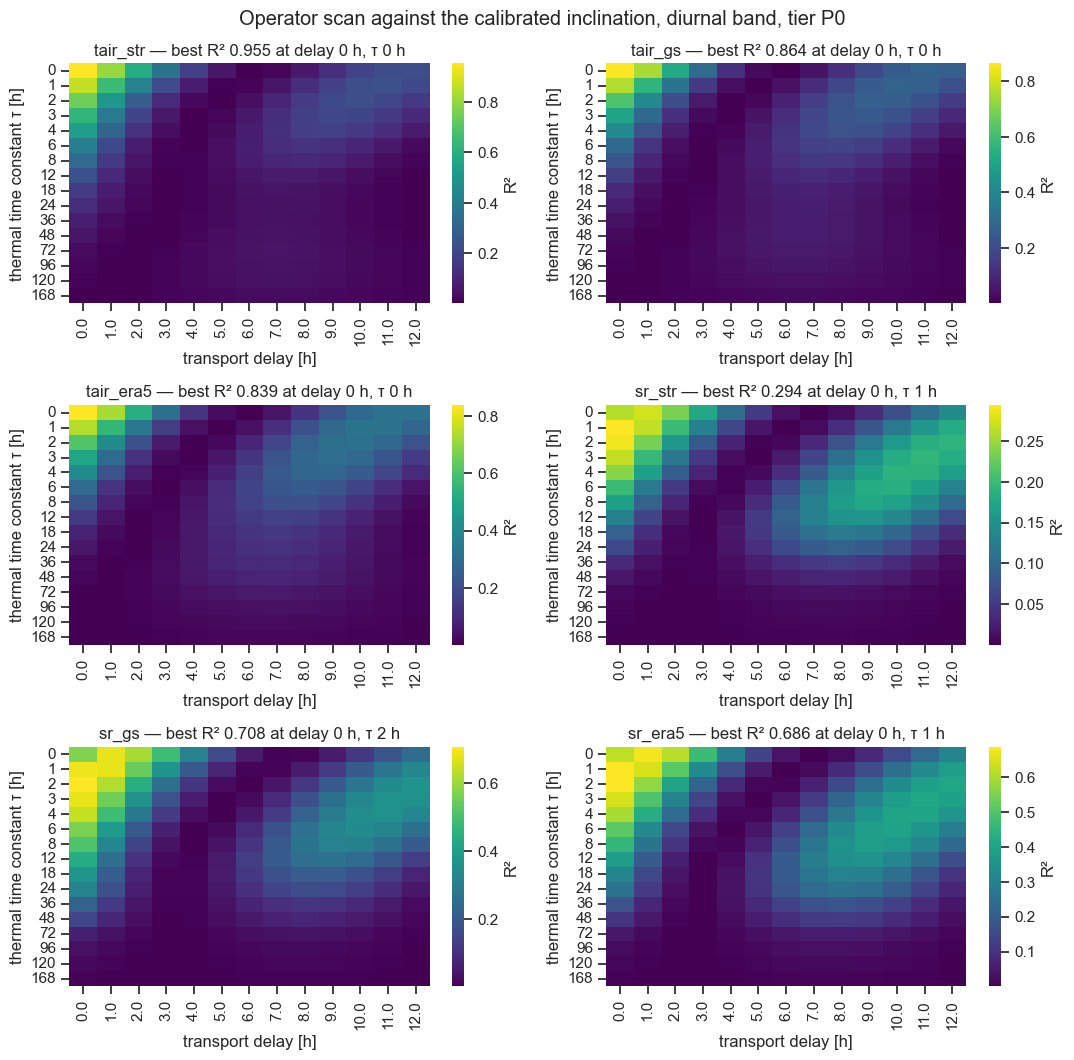

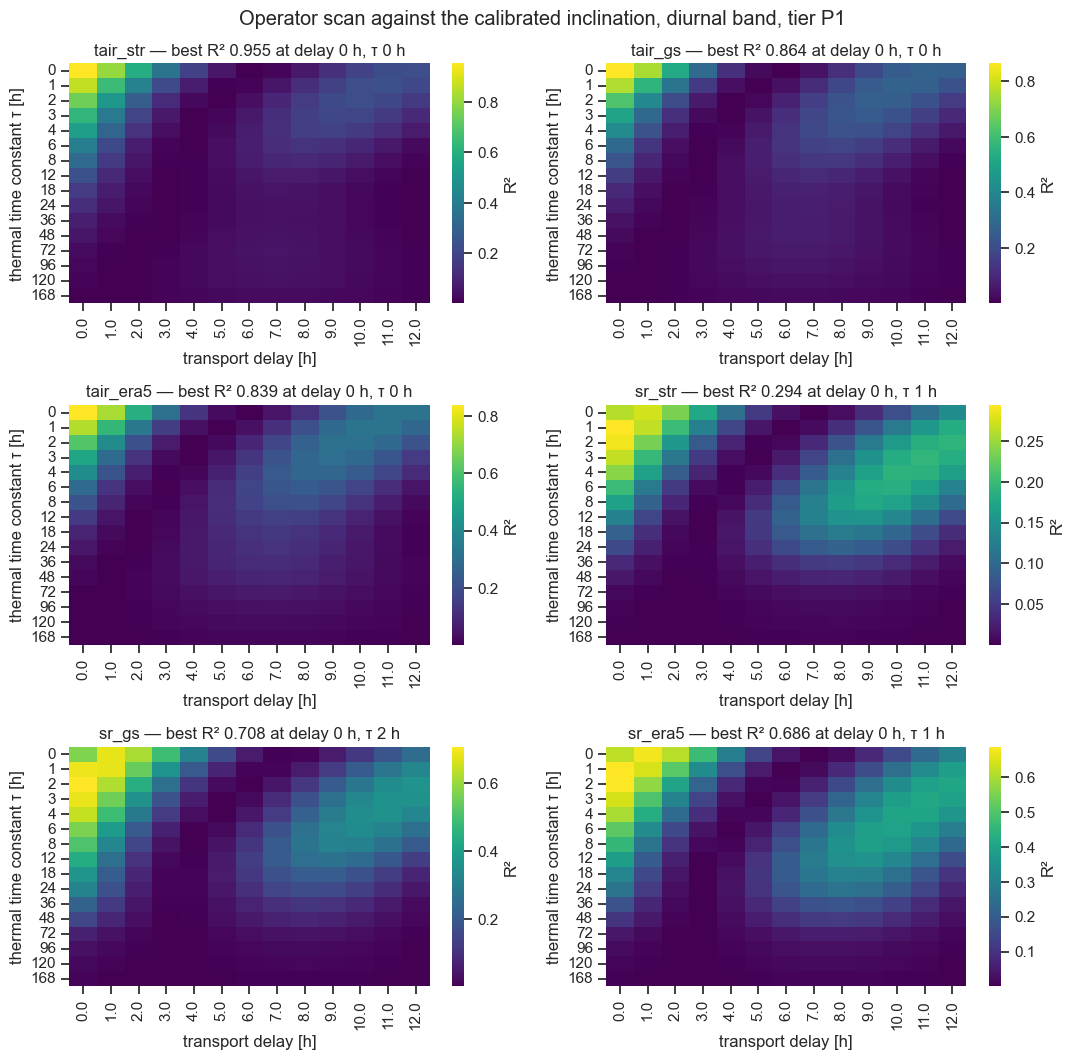

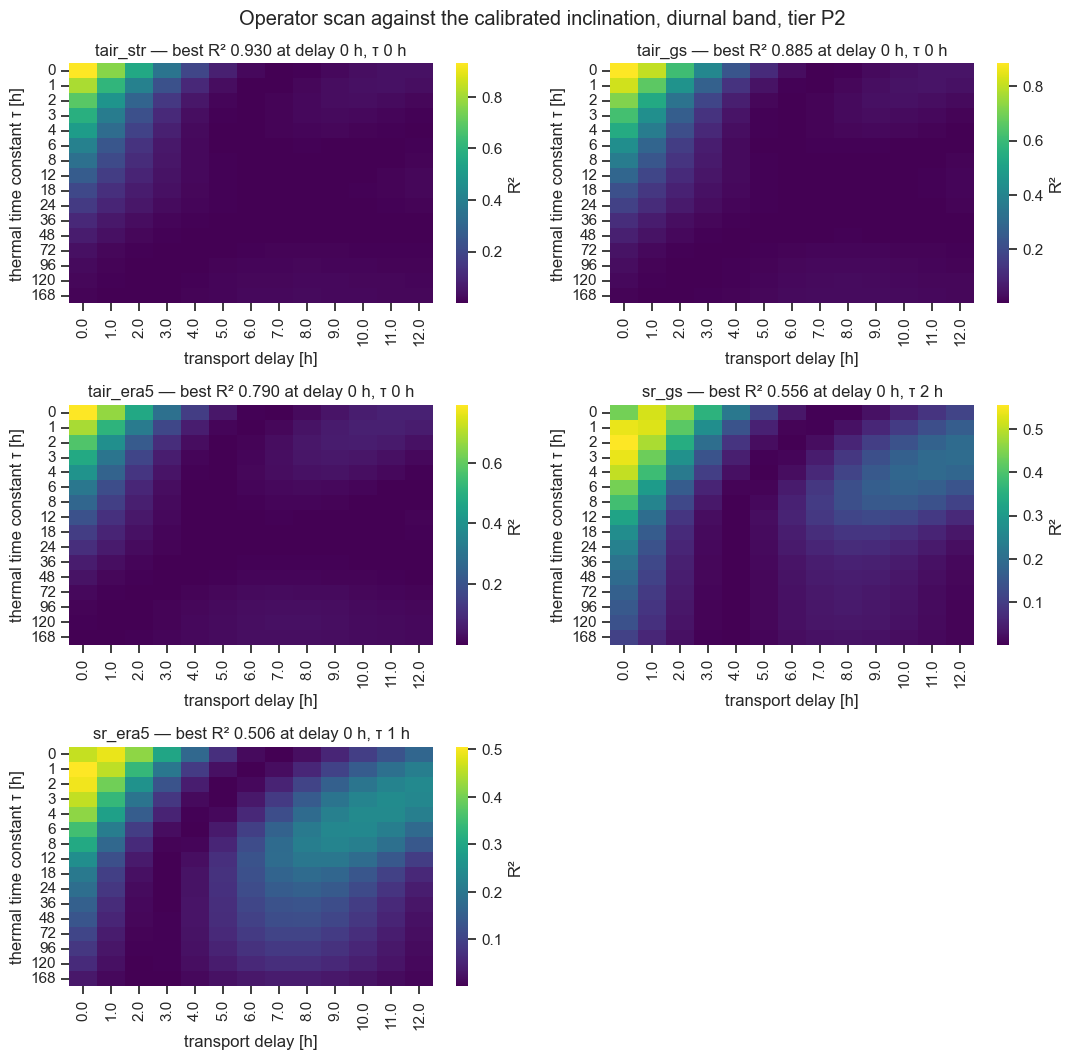

In [28]:
for tier, scans in operator_scans.items():
    ip.plot_operator_heatmaps(
        scans,
        title=f'Operator scan against the calibrated inclination, '
              f'diurnal band, tier {tier}',
        save_path=OUTPUT_DIR, filename=f'P_F08_operators_{tier}')
    plt.show()

## Step 5e · The signed-delay control on solar radiation

The scan above is bounded at non-negative delays, because solar radiation is an
external forcing and a forcing must precede the response it causes. That bound
is right for *use* — a lead cannot be applied by a forecasting system, which
would need the driver's future values at the moment the forecast is issued —
but it also hides a diagnostic. If the optimum for a channel genuinely sits at
a negative delay, the bound reports the boundary instead of the anomaly.

Scanning signed delays makes the anomaly visible. A negative optimum for a
radiation channel is not a physical lead; it is a signature of a defect in that
channel. This is the third independent test of the on-structure pyranometer,
after its non-zero night-time floor and its impossible solar-noon phase, and it
is run on tier P0 where all three sources coexist — which removes the analysis
window as an alternative explanation.

In [29]:
signed_rows = []
for tier in TIERS:
    block = pc.longest_block(inventory_blocks, tier)
    if block is None:
        continue
    window = df_screened.loc[block['start']:block['end']].copy()
    drivers = [c for c in ('sr_str', 'sr_gs', 'sr_era5')
               if c in window.columns and window[c].notna().sum() > 100]
    if not drivers:
        continue

    banded = window[[TARGET] + drivers].apply(
        lambda s: ip.band_limit(s, DETREND_HOURS, SAMPLING_HOURS))
    ccf = tc.cross_correlation(banded, TARGET, drivers,
                               max_lag_steps=MAX_DELAY_H, differenced=False)
    peaks = tc.peak_lags(ccf, sampling_hours=SAMPLING_HOURS,
                         match_sign=True).reset_index()
    peaks.insert(0, 'tier', tier)
    peaks.insert(1, 'block', block['block'])
    signed_rows.append(peaks)

signed_delays = pd.concat(signed_rows, ignore_index=True)
display(signed_delays)
signed_delays.to_csv(f'{OUTPUT_DIR}/P_19_signed_delay_sr.csv', index=False)

proxy_peaks = signed_delays[signed_delays['driver'].isin(['sr_gs', 'sr_era5'])]
assert (proxy_peaks['peak_lag_hours'] >= 0).all(), (
    'forcing guard: a proxy radiation channel peaks at a negative delay, '
    'which points at the harmonisation or the clock correction rather than at '
    'the wall\n' + proxy_peaks.to_string())
print('\nForcing guard passed: both proxy radiation channels peak at a '
      'non-negative delay.')

on_structure_peaks = signed_delays[signed_delays['driver'] == 'sr_str']
if len(on_structure_peaks) and (on_structure_peaks['peak_lag_hours'] < 0).any():
    print('\nThe on-structure radiation channel peaks at a negative delay. '
          'A forcing cannot lead its own response, so this is a further '
          'symptom of the defect already established from the night-time '
          'floor and the solar-noon phase.')

,tier,block,driver,peak_corr,peak_lag_steps,peak_lag_hours,corr_at_lag0
0,P0,P0-cur1,sr_str,-0.5241,1,1.0,-0.5118
1,P0,P0-cur1,sr_gs,-0.8251,1,1.0,-0.7550
2,P0,P0-cur1,sr_era5,-0.8212,1,1.0,-0.7860
3,P1,P1-cur1,sr_str,-0.5241,1,1.0,-0.5118
4,P1,P1-cur1,sr_gs,-0.8251,1,1.0,-0.7550
5,P1,P1-cur1,sr_era5,-0.8212,1,1.0,-0.7860
6,P2,P2-leg1,sr_gs,-0.7212,1,1.0,-0.6611
7,P2,P2-leg1,sr_era5,-0.6997,1,1.0,-0.6785



Forcing guard passed: both proxy radiation channels peak at a non-negative delay.


## Step 5f · What solar radiation adds once temperature is present

Radiation heats the air, so air temperature and solar radiation are strongly
coupled and a marginal correlation between radiation and the target largely
re-measures the temperature relationship. Two steps separate them.

The **variance inflation factor** quantifies how far the two duplicate one
another before any coefficient is read for interpretation. The **joint fit**
then enters both together and reports the increment in explained variance over
the temperature-only fit, with Newey–West standard errors at 24 lags.

This is the question the imputation study inherits: whether a radiation channel
is worth carrying as a regressor at all once temperature is available.

In [30]:
contribution_cols = [c for c in CHANNEL_ORDER if c in df_screened.columns]

contribution_rows = []
for tier in TIERS:
    for domain in ('levels', 'differences'):
        frame = (pc.tier_frame(df_screened, inventory_blocks,
                               tier)[contribution_cols]
                 if domain == 'levels'
                 else pc.tier_differences(df_screened, inventory_blocks, tier,
                                          cols=contribution_cols))
        for source in pc.SOURCES:
            tair_col, sr_col = f'tair_{source}', f'sr_{source}'
            if not {tair_col, sr_col, TARGET}.issubset(frame.columns):
                continue
            data = frame[[TARGET, tair_col, sr_col]].dropna()
            if len(data) < MIN_OVERLAP_DAYS * 24:
                continue

            vif = ip.vif_table(data, [tair_col, sr_col])
            alone = tc.multivariate_fit(data, TARGET, [tair_col], hac_lags=24)
            joint = tc.multivariate_fit(data, TARGET, [tair_col, sr_col],
                                        hac_lags=24)

            contribution_rows.append({
                'tier': tier,
                'domain': domain,
                'source': source,
                'n': int(len(data)),
                'VIF': float(vif.loc[tair_col, 'VIF']),
                'r_tair_sr': round(float(data[tair_col].corr(data[sr_col])), 4),
                'r2_tair_only': round(float(alone.rsquared), 4),
                'r2_joint': round(float(joint.rsquared), 4),
                'delta_r2': round(float(joint.rsquared - alone.rsquared), 4),
                'slope_tair_joint': round(float(joint.params[tair_col]), 4),
                'slope_sr_joint': round(float(joint.params[sr_col]), 5),
                'se_sr_joint': round(float(joint.bse[sr_col]), 5),
                't_sr_joint': round(float(joint.tvalues[sr_col]), 2),
            })

contribution = pd.DataFrame(contribution_rows)
display(contribution)
contribution.to_csv(f'{OUTPUT_DIR}/P_20_radiation_contribution.csv', index=False)

print('\nWhere radiation earns its place — the joint fit gains at least one '
      'point of explained variance and the radiation term clears |t| = 2:')
earns = contribution[(contribution['delta_r2'] >= 0.01)
                     & (contribution['t_sr_joint'].abs() >= 2.0)]
display(earns if len(earns) else 'nowhere on these windows')

,tier,domain,source,n,VIF,r_tair_sr,r2_tair_only,r2_joint,delta_r2,slope_tair_joint,slope_sr_joint,se_sr_joint,t_sr_joint
0,P0,levels,str,8192,1.07,0.2599,0.9074,0.9194,0.0120,-4.7461,0.01520,0.00077,19.70
1,P0,levels,gs,8188,1.38,0.5255,0.8828,0.8865,0.0037,-5.0358,0.01236,0.00130,9.52
2,P0,levels,era5,8196,1.51,0.5813,0.8684,0.8785,0.0101,-5.1340,0.02002,0.00149,13.41
3,P0,differences,str,8152,1.37,0.5195,0.7060,0.7186,0.0126,-2.7647,-0.00413,0.00040,-10.22
4,P0,differences,gs,8145,1.57,0.6023,0.3392,0.3491,0.0099,-2.0827,-0.00543,0.00084,-6.45
5,P0,differences,era5,8159,2.01,0.7088,0.3247,0.3552,0.0306,-1.6160,-0.01298,0.00104,-12.48
6,P1,levels,str,8192,1.07,0.2599,0.9074,0.9194,0.0120,-4.7461,0.01520,0.00077,19.70
7,P1,levels,gs,9212,1.39,0.5273,0.8804,0.8839,0.0035,-4.9717,0.01179,0.00125,9.44
8,P1,levels,era5,9222,1.52,0.5850,0.8633,0.8726,0.0094,-5.0443,0.01903,0.00146,13.06
9,P1,differences,str,8152,1.37,0.5195,0.7060,0.7186,0.0126,-2.7647,-0.00413,0.00040,-10.22



Where radiation earns its place — the joint fit gains at least one point of explained variance and the radiation term clears |t| = 2:


,tier,domain,source,n,VIF,r_tair_sr,r2_tair_only,r2_joint,delta_r2,slope_tair_joint,slope_sr_joint,se_sr_joint,t_sr_joint
0,P0,levels,str,8192,1.07,0.2599,0.9074,0.9194,0.0120,-4.7461,0.01520,0.00077,19.70
2,P0,levels,era5,8196,1.51,0.5813,0.8684,0.8785,0.0101,-5.1340,0.02002,0.00149,13.41
3,P0,differences,str,8152,1.37,0.5195,0.7060,0.7186,0.0126,-2.7647,-0.00413,0.00040,-10.22
5,P0,differences,era5,8159,2.01,0.7088,0.3247,0.3552,0.0306,-1.6160,-0.01298,0.00104,-12.48
6,P1,levels,str,8192,1.07,0.2599,0.9074,0.9194,0.0120,-4.7461,0.01520,0.00077,19.70
9,P1,differences,str,8152,1.37,0.5195,0.7060,0.7186,0.0126,-2.7647,-0.00413,0.00040,-10.22
10,P1,differences,gs,9163,1.57,0.6012,0.3394,0.3500,0.0106,-2.0386,-0.00555,0.00081,-6.88
11,P1,differences,era5,9180,2.00,0.7068,0.3254,0.3569,0.0315,-1.5754,-0.01301,0.00098,-13.27
15,P2,differences,era5,29665,1.67,0.6342,0.3233,0.4038,0.0805,-1.0430,-0.01581,0.00035,-45.29


## Step 6 · Verdict, and the feature specification

Three axes: availability during the intervals that must be reconstructed,
agreement with the on-structure sensor, and relationship with the target.

In [31]:
# sensor_raw was loaded in Step 5a for the target verification and is reused
# here rather than read a second time.
#
# The joined frame starts in January 2018 because ERA5 does, while the archive
# starts in July. Availability during target gaps is only meaningful over the
# archive's own span, so the mask is built on the sensor index and the frame is
# restricted to it.
span = df.index.intersection(sensor_raw.index)
absent = sensor_raw['inc'].isna().reindex(span).fillna(True)
on_span = df.loc[span]

# Radiation is priced on the same two axes as temperature. A radiation channel
# cannot enter the feature specification until its availability during the
# intervals that must be reconstructed is known.
availability = pd.DataFrame([
    {'quantity': q,
     'source': s,
     'coverage_of_span_%': round(
         100.0 * on_span[f'{q}_{s}'].notna().mean(), 1),
     'present_during_target_gaps_%': round(
         100.0 * on_span.loc[absent, f'{q}_{s}'].notna().mean(), 1)}
    for q in ('tair', 'sr') for s in pc.SOURCES
    if f'{q}_{s}' in df.columns]).set_index(['quantity', 'source'])
display(availability)
availability.to_csv(f'{OUTPUT_DIR}/P_22_sr_availability.csv')
print(f'Measured over {len(span)} hourly slots of the archive span, '
      f'of which {int(absent.sum())} are missing the inclinometer.')

coverage_of_span_%  present_during_target_gaps_%
quantity source                                                  
tair     str                   70.1                           0.0
         gs                    94.8                          94.3
         era5                  99.4                          99.6
sr       str                   12.7                           0.0
         gs                    94.9                          94.4
         era5                  99.4                          99.6

Measured over 70561 hourly slots of the archive span, of which 21098 are missing the inclinometer.


In [32]:
p0_rel = relationship_tiers[relationship_tiers['tier'] == 'P0']
tair_agree = agreement[(agreement['quantity'] == 'tair')
                       & (agreement['reference'] == 'str')]
sr_agree = agreement[agreement['quantity'] == 'sr']

verdict_rows = [
    {'question': 'do the sources agree in absolute terms?',
     'answer': '; '.join(
         f'{pc.SOURCE_LABEL[r["compared"]]}: bias {r["bias"]:+.2f} degC, '
         f'MAE {r["MAE"]:.2f}, limits of agreement '
         f'{r["loa_lower"]:+.1f} to {r["loa_upper"]:+.1f}'
         for _, r in tair_agree.iterrows())},
    {'question': 'do the radiation channels agree?',
     'answer': '; '.join(
         f'{r["reference"]}-{r["compared"]}: r {r["r"]:.3f}, '
         f'MAE {r["MAE"]:.1f} W/m2 over {r["overlap_days"]:.0f} days'
         for _, r in sr_agree.iterrows())},
    {'question': 'what does the daylight mask change for radiation?',
     'answer': '; '.join(
         f'{r["reference"]}-{r["compared"]}: r {r["r"]:.3f} in daylight'
         for _, r in daylight_agreement.iterrows())},
    {'question': 'do they agree on the daily cycle?',
     'answer': '; '.join(
         f'{pc.SOURCE_LABEL[s]}: amplitude ratio '
         f'{diurnal.loc[("tair", s), "amplitude_ratio"]:.2f}, peak hour '
         f'{int(diurnal.loc[("tair", s), "peak_hour"])}'
         for s in pc.SOURCES if ('tair', s) in diurnal.index)},
    {'question': 'how much agreement survives differencing?',
     'answer': '; '.join(
         f'{pc.SOURCE_LABEL[r["compared"]]}: r {r["r"]:.3f} in differences '
         f'against {level_r.get(("tair", r["reference"], r["compared"])):.3f} '
         f'in levels'
         for _, r in differences[(differences['quantity'] == 'tair')
                                 & (differences['reference'] == 'str')].iterrows())},
    {'question': 'what did the pooled span cost?',
     'answer': '; '.join(
         f'{q}·{s}·{d}: {row["r_pooled_span"]:+.3f} pooled against '
         f'{row["r_tier_P0"]:+.3f} in tier P0'
         for (q, s, d), row in contrast_tiers.iterrows()
         if q in ('tair', 'sr') and d == 'differences')},
    {'question': 'do all sources give the same sign against the target?',
     'answer': ('yes, all negative'
                if (p0_rel[p0_rel['quantity'].isin(['tair', 'sr'])]['r']
                    < 0).all() else
                'NO — a source reverses sign, which reopens docs 7.5')},
    {'question': 'relationship with the target in tier P0, levels',
     'answer': '; '.join(
         f'{r["quantity"]}·{pc.SOURCE_LABEL[r["source"]]}: r {r["r"]:+.3f}, '
         f'slope {r["slope_mdeg_per_unit"]:+.3f}'
         for _, r in p0_rel[(p0_rel['domain'] == 'levels')
                            & (p0_rel['quantity'].isin(['tair', 'sr']))].iterrows())},
    {'question': 'relationship with the target in tier P0, differences',
     'answer': '; '.join(
         f'{r["quantity"]}·{pc.SOURCE_LABEL[r["source"]]}: r {r["r"]:+.3f}, '
         f'slope {r["slope_mdeg_per_unit"]:+.3f}'
         for _, r in p0_rel[(p0_rel['domain'] == 'differences')
                            & (p0_rel['quantity'].isin(['tair', 'sr']))].iterrows())},
    {'question': 'transport delay and inertia, diurnal band',
     'answer': '; '.join(
         f'{r["tier"]}·{r["driver"]}: delay {r["delay_h"]:g} h, '
         f'tau {r["tau_h"]:g} h, R2 {r["r2"]:.3f}'
         for _, r in operators_diurnal.iterrows())},
    {'question': 'does any radiation channel lead the response?',
     'answer': '; '.join(
         f'{r["tier"]}·{r["driver"]}: {r["peak_lag_hours"]:+.0f} h'
         for _, r in signed_delays.iterrows())},
    {'question': 'does radiation add anything beyond temperature?',
     'answer': '; '.join(
         f'{r["tier"]}·{r["domain"]}·{r["source"]}: delta R2 '
         f'{r["delta_r2"]:+.3f}, t {r["t_sr_joint"]:+.1f}'
         for _, r in contribution.iterrows())},
    {'question': 'availability when the target is missing',
     'answer': '; '.join(
         f'{q}·{pc.SOURCE_LABEL[s]}: '
         f'{availability.loc[(q, s), "present_during_target_gaps_%"]:.1f} %'
         for q, s in availability.index)},
]
verdicts = pd.DataFrame(verdict_rows).set_index('question')
display(verdicts)
verdicts.to_csv(f'{OUTPUT_DIR}/P_11_verdicts.csv')

,answer
question,
do the sources agree in absolute terms?,"ground station: bias +0.37 degC, MAE 1.12, lim..."
do the radiation channels agree?,"str-gs: r 0.744, MAE 153.9 W/m2 over 368 days;..."
what does the daylight mask change for radiation?,str-gs: r 0.705 in daylight; str-era5: r 0.700...
do they agree on the daily cycle?,"on-structure: amplitude ratio 1.00, peak hour ..."
how much agreement survives differencing?,ground station: r 0.699 in differences against...
what did the pooled span cost?,tair·str·differences: -0.154 pooled against -0...
do all sources give the same sign against the target?,"yes, all negative"
"relationship with the target in tier P0, levels","tair·on-structure: r -0.953, slope -4.602; tai..."
"relationship with the target in tier P0, differences","tair·on-structure: r -0.840, slope -3.010; tai..."


### The feature specification the imputation study needs

The chosen source per channel, its identified operator, and the window over
which it can be trusted.

In [33]:
spec_rows = []
for _, row in operators_diurnal.iterrows():
    driver = row['driver']
    quantity, source = driver.rsplit('_', 1)
    if quantity not in ('tair', 'sr'):
        continue
    if (quantity, source) not in availability.index:
        continue
    rel = relationship_tiers[(relationship_tiers['tier'] == row['tier'])
                             & (relationship_tiers['quantity'] == quantity)
                             & (relationship_tiers['source'] == source)
                             & (relationship_tiers['domain'] == 'differences')]
    gaps = float(availability.loc[(quantity, source),
                                  'present_during_target_gaps_%'])
    spec_rows.append({
        'channel': driver,
        'tier': row['tier'],
        'source': pc.SOURCE_LABEL[source],
        'delay_h': row['delay_h'],
        'tau_h': row['tau_h'],
        'r2_diurnal_band': row['r2'],
        'r_differences': float(rel['r'].iloc[0]) if len(rel) else np.nan,
        'available_during_gaps_%': gaps,
        'usable_for_reconstruction': bool(gaps > 70.0),
    })
specification = pd.DataFrame(spec_rows).set_index(['channel', 'tier'])
display(specification)
specification.to_csv(f'{OUTPUT_DIR}/P_12_feature_specification.csv')

print('\nChannels usable for reconstruction (present when the target is not):')
for (channel, tier), row in specification.iterrows():
    if row['usable_for_reconstruction']:
        print(f'  {channel} ({tier}): delay {row["delay_h"]:g} h, '
              f'tau {row["tau_h"]:g} h, '
              f'{row["available_during_gaps_%"]:.1f} % available')

,,source,delay_h,tau_h,r2_diurnal_band,r_differences,available_during_gaps_%,usable_for_reconstruction
channel,tier,,,,,,,
tair_str,P0,on-structure,0.0,0.0,0.9547,-0.8403,0.0,False
tair_gs,P0,ground station,0.0,0.0,0.8645,-0.5824,94.3,True
tair_era5,P0,ERA5 reanalysis,0.0,0.0,0.8393,-0.5698,99.6,True
sr_str,P0,on-structure,0.0,1.0,0.2942,-0.5326,0.0,False
sr_gs,P0,ground station,0.0,2.0,0.7078,-0.4295,94.4,True
sr_era5,P0,ERA5 reanalysis,0.0,1.0,0.6863,-0.5272,99.6,True
tair_str,P1,on-structure,0.0,0.0,0.9547,-0.8421,0.0,False
tair_gs,P1,ground station,0.0,0.0,0.8645,-0.5826,94.3,True
tair_era5,P1,ERA5 reanalysis,0.0,0.0,0.8393,-0.5704,99.6,True



Channels usable for reconstruction (present when the target is not):
  tair_gs (P0): delay 0 h, tau 0 h, 94.3 % available
  tair_era5 (P0): delay 0 h, tau 0 h, 99.6 % available
  sr_gs (P0): delay 0 h, tau 2 h, 94.4 % available
  sr_era5 (P0): delay 0 h, tau 1 h, 99.6 % available
  tair_gs (P1): delay 0 h, tau 0 h, 94.3 % available
  tair_era5 (P1): delay 0 h, tau 0 h, 99.6 % available
  sr_gs (P1): delay 0 h, tau 2 h, 94.4 % available
  sr_era5 (P1): delay 0 h, tau 1 h, 99.6 % available
  tair_gs (P2): delay 0 h, tau 0 h, 94.3 % available
  tair_era5 (P2): delay 0 h, tau 0 h, 99.6 % available
  sr_gs (P2): delay 0 h, tau 2 h, 94.4 % available
  sr_era5 (P2): delay 0 h, tau 1 h, 99.6 % available
